In [7]:
from pathlib import Path

data_dir = Path(r'C:\Users\eajaj\Downloads\-Human-AI-Technical-Test-\data\ravdess\Audio_Song_Actors_01-24')
wav_files = list(data_dir.rglob("*.wav"))

print("Total files:", len(wav_files))

Total files: 1012


In [8]:
filenames = [f.name for f in wav_files]

duplicates = [f for f in set(filenames) if filenames.count(f) > 1]

print("Duplicate files:", duplicates)

Duplicate files: []


In [9]:
import librosa

bad_files = []

for f in wav_files:
    try:
        y, sr = librosa.load(f, sr=None)
    except:
        bad_files.append(f)

print("Corrupted files:", len(bad_files))

c:\Users\eajaj\Downloads\-Human-AI-Technical-Test-\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Corrupted files: 0


In [10]:
durations = []

for f in wav_files:
    y, sr = librosa.load(f)
    durations.append(len(y) / sr)

import numpy as np

print("Min duration:", np.min(durations))
print("Max duration:", np.max(durations))
print("Mean duration:", np.mean(durations))

Min duration: 3.5035374149659866
Max duration: 6.3730612244897955
Mean duration: 4.649230951932815


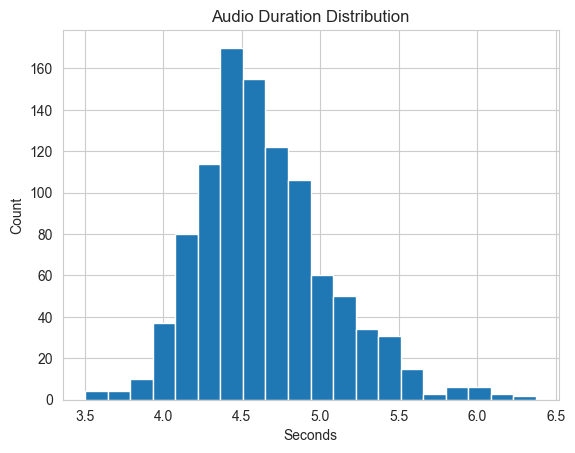

In [11]:
import matplotlib.pyplot as plt

plt.hist(durations, bins=20)
plt.title("Audio Duration Distribution")
plt.xlabel("Seconds")
plt.ylabel("Count")
plt.show()

In [12]:
import sys
sys.path.append("..")

from src.audio.task1_audio_processing import parse_ravdess_filename

labels = []

for f in wav_files:
    meta = parse_ravdess_filename(str(f))
    labels.append(meta["emotion_label"])

import pandas as pd

df_raw = pd.DataFrame({"emotion": labels})

df_raw["emotion"].value_counts()

emotion
calm       184
happy      184
sad        184
angry      184
fearful    184
neutral     92
Name: count, dtype: int64

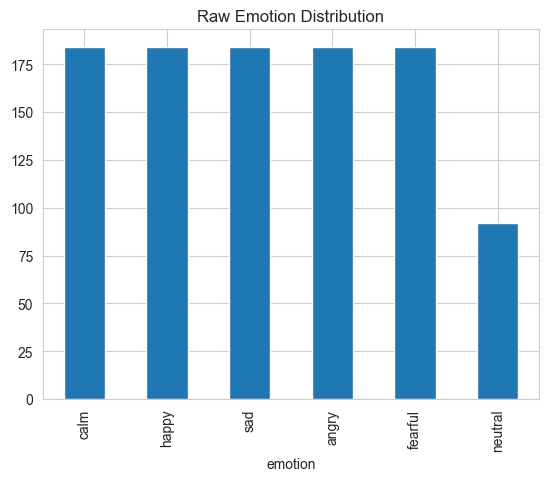

In [13]:
df_raw["emotion"].value_counts().plot(kind="bar")
plt.title("Raw Emotion Distribution")
plt.show()

In [14]:
silent_files = []

for f in wav_files[:100]:  # sample first
    y, sr = librosa.load(f)
    if np.max(np.abs(y)) < 0.01:
        silent_files.append(f)

print("Nearly silent files:", len(silent_files))

Nearly silent files: 0


EDA Insights:
- No duplicate or corrupted files detected
- Audio durations are consistent (~3–5 seconds)
- Dataset is balanced across emotion classes
- No silent or empty recordings found
- Dataset quality is high and suitable for ML pipeline